<a href="https://colab.research.google.com/github/amankiitg/LLM_Prod/blob/main/Reditt_Text_Clustering_and_Topic_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>Text Clustering and Topic Modeling</h1>
<i>Clustering documents using a wide variety of language models.</i>



### [OPTIONAL] - Installing Packages on <img src="https://colab.google/static/images/icons/colab.png" width=100>

If you are viewing this notebook on Google Colab (or any other cloud vendor), you need to **uncomment and run** the following codeblock to install the dependencies for this chapter:

---

💡 **NOTE**: We will want to use a GPU to run the examples in this notebook. In Google Colab, go to
**Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**.

---


In [3]:
!pip install asyncpraw

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.4/196.4 kB 3.9 MB/s eta 0:00:00


In [4]:
import asyncio
import asyncpraw
import nest_asyncio
import json
import numpy as np
import re
import string

# --------------------
# Text cleaning helper
# --------------------
def clean_text(text):
    """Cleans text by removing URLs, punctuation, and lowercasing."""
    text = re.sub(r'http\S+|https\S+', '', text)   # Remove URLs
    text = text.replace('\n', ' ')                 # Remove newlines
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    return text.lower().strip()

def extract_comment_bodies(comments):
    """Recursively extracts bodies and scores for thresholding."""
    bodies, scores = [], []
    for comment in comments:
        bodies.append(comment['body'])
        scores.append(comment['score'])
        if comment.get('replies'):
            child_bodies, child_scores = extract_comment_bodies(comment['replies'])
            bodies.extend(child_bodies)
            scores.extend(child_scores)
    return bodies, scores

# --------------------
# Main Scraper
# --------------------
async def scrape():
    async with asyncpraw.Reddit(
        client_id="glnTvdUs1KFycKy5vEsOig",
        client_secret="ET1IgiyCztIxhXSwnFIYbTs3eq2nRQ",
        user_agent="Topic Modeler"
    ) as reddit:

        url = "https://www.reddit.com/r/ChatGPT/comments/1mkae1l/gpt5_ama_with_openais_sam_altman_and_some_of_the/"
        submission = await reddit.submission(url=url)

        async def extract_comment(comment):
            return {
                "author": str(comment.author),
                "body": comment.body,
                "score": comment.score,
                "replies": [await extract_comment(reply) async for reply in comment.replies]
            }

        # Build post object
        post_data = {
            "title": submission.title,
            "author": str(submission.author),
            "score": submission.score,
            "url": submission.url,
            "selftext": submission.selftext,
            "comments": []
        }

        # Load comments
        await submission.comments.replace_more(limit=None)
        for top_comment in submission.comments:
            post_data["comments"].append(await extract_comment(top_comment))

        # Flatten scores for median threshold
        _, all_scores = extract_comment_bodies(post_data["comments"])
        median_score = np.median(all_scores) if all_scores else 0

        # --------------------
        # Filter + transform comments
        # --------------------
        def filter_and_transform(comments):
            """Filter by median score and create title/abstract."""
            result = []
            for c in comments:
                if c['score'] >= median_score:
                    result.append({
                        "title": clean_text(c['body'])[:60],   # First 60 chars as title
                        "abstract": clean_text(c['body']),     # Full cleaned body
                        "score": c['score'],
                        "author": c['author']
                    })
                if c.get('replies'):
                    result.extend(filter_and_transform(c['replies']))
            return result

        post_data["comments"] = filter_and_transform(post_data["comments"])
        post_data["median_score_threshold"] = median_score

        # Dump JSON
        with open("reddit_post_filtered.json", "w", encoding="utf-8") as f:
            json.dump(post_data, f, indent=2, ensure_ascii=False)

        print("✅ Filtered post data saved to reddit_post_filtered.json")

# --------------------
# Run safely with nest_asyncio
# --------------------
nest_asyncio.apply()
asyncio.run(scrape())


✅ Filtered post data saved to reddit_post_filtered.json


/tmp/ipython-input-3660819704.py:65: DeprecationWarning: Using CommentForest as an asynchronous iterator has been deprecated and will be removed in a future version.
  post_data["comments"].append(await extract_comment(top_comment))
/tmp/ipython-input-3660819704.py:49: DeprecationWarning: Using CommentForest as an asynchronous iterator has been deprecated and will be removed in a future version.
  "replies": [await extract_comment(reply) async for reply in comment.replies]


# **Load Reditt Data**

In [5]:
import json

with open("/content/reddit_post_filtered.json", "r", encoding="utf-8") as f:
    reddit_data = json.load(f)

# Recursive extractor for title and abstract
def extract_title_abstract(comments):
    result = []
    for c in comments:
        result.append({
            "title": c["title"],
            "abstract": c["abstract"]
        })
        if c.get("replies"):
            result.extend(extract_title_abstract(c["replies"]))
    return result

# Extract only title and abstract
titles_and_abstracts = extract_title_abstract(reddit_data["comments"])

# Display first 10
for item in titles_and_abstracts[:10]:
    print(item)


{'title': 'i see that em dash', 'abstract': 'i see that em dash'}
{'title': 'its not an em dash — its a pause that demands attention', 'abstract': 'its not an em dash — its a pause that demands attention'}
{'title': 'can you mark the other cohosts their answers are buried and ', 'abstract': 'can you mark the other cohosts their answers are buried and unhighlighted and the only way you can find them at present is by checking each profiles comment history manually   currently the filter for answered misses every other cohost reply other than sam altman making the ama much harder to navigate  or provide some other way to see them thanks'}
{'title': 'only uopenai can i think theres a limit to the number of par', 'abstract': 'only uopenai can i think theres a limit to the number of participants'}
{'title': 'ah thats a bother perhaps sticky links to them in a comment ', 'abstract': 'ah thats a bother perhaps sticky links to them in a comment after the ama ends its kind of silly that theres b

# **A Common Pipeline for Text Clustering**

In [ ]:
# # Extract metadata and convert to standard list
abstracts = [t['abstract'] for t in titles_and_abstracts]
titles = [t['title'] for t in titles_and_abstracts]



import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def find_optimal_k(embeddings, k_min=2, k_max=15, random_state=42):
    inertias = []
    sil_scores = []
    K = range(k_min, k_max + 1)

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=random_state).fit(embeddings)
        inertias.append(kmeans.inertia_)
        sil_scores.append(silhouette_score(embeddings, kmeans.labels_))

    # Plot elbow + silhouette scores
    fig, ax1 = plt.subplots()

    color = "tab:blue"
    ax1.set_xlabel("Number of clusters (k)")
    ax1.set_ylabel("Inertia", color=color)
    ax1.plot(K, inertias, marker="o", color=color, label="Inertia (Elbow)")
    ax1.tick_params(axis="y", labelcolor=color)

    ax2 = ax1.twinx()
    color = "tab:orange"
    ax2.set_ylabel("Silhouette Score", color=color)
    ax2.plot(K, sil_scores, marker="s", color=color, label="Silhouette")
    ax2.tick_params(axis="y", labelcolor=color)

    fig.tight_layout()
    plt.title("Elbow & Silhouette Analysis for Optimal k")
    plt.show()

    # Choose best k based on silhouette score
    best_k = K[sil_scores.index(max(sil_scores))]
    print(f"✅ Best k based on silhouette score: {best_k}")

    return best_k

best_k = find_optimal_k(reduced_embeddings, k_min=2, k_max=15)

# Run final KMeans with best k
kmeans_model = KMeans(n_clusters=best_k, random_state=42).fit(reduced_embeddings)
clusters = kmeans_model.labels_
print(f"Number of clusters: {len(set(clusters))}")

## **1. Embedding Documents**

In [6]:
# # Extract metadata and convert to standard list
abstracts = [t['abstract'] for t in titles_and_abstracts]
titles = [t['title'] for t in titles_and_abstracts]

In [7]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model = SentenceTransformer('thenlper/gte-small')
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/87 [00:00<?, ?it/s]

In [8]:
# Check the dimensions of the resulting embeddings
embeddings.shape

(2769, 384)

## **2. Reducing the Dimensionality of Embeddings**

In [11]:
from umap import UMAP

# We reduce the input embeddings from 384 dimenions to 5 dimenions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [19]:
from sklearn.decomposition import PCA

# We reduce the input embeddings from 384 dimensions to 5 dimensions
pca_model = PCA(n_components=5, random_state=42)
reduced_embeddings = pca_model.fit_transform(embeddings)

## **3. Cluster the Reduced Embeddings**

In [30]:
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=10, metric='euclidean', cluster_selection_method='eom'
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

/usr/local/lib/python3.12/dist-packages/hdbscan/plots.py:448: SyntaxWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


35

In [34]:
from sklearn.cluster import DBSCAN
import numpy as np

# Fit DBSCAN on reduced embeddings
dbscan_model = DBSCAN(
    eps=0.001,        # max distance between points in a neighborhood
    min_samples=5, # minimum points to form a cluster
    metric='euclidean'
).fit(reduced_embeddings)

clusters = dbscan_model.labels_

# How many clusters did we generate?
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)  # exclude noise (-1)
print(f"Number of clusters: {n_clusters}")

Number of clusters: 8


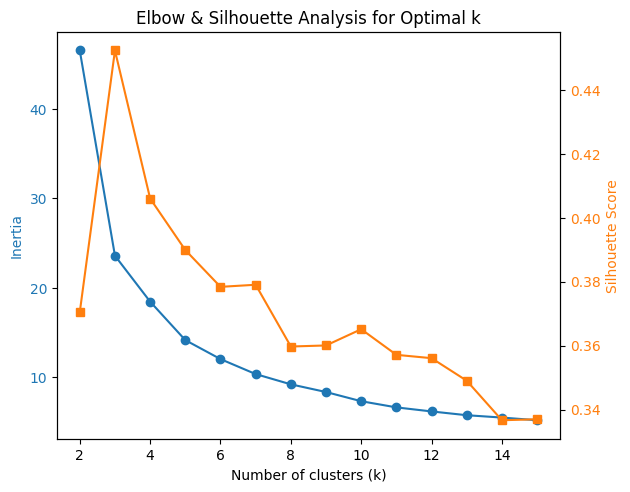

✅ Best k based on silhouette score: 3
Number of clusters: 3


In [35]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def find_optimal_k(embeddings, k_min=2, k_max=15, random_state=42):
    inertias = []
    sil_scores = []
    K = range(k_min, k_max + 1)

    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=random_state).fit(embeddings)
        inertias.append(kmeans.inertia_)
        sil_scores.append(silhouette_score(embeddings, kmeans.labels_))

    # Plot elbow + silhouette scores
    fig, ax1 = plt.subplots()

    color = "tab:blue"
    ax1.set_xlabel("Number of clusters (k)")
    ax1.set_ylabel("Inertia", color=color)
    ax1.plot(K, inertias, marker="o", color=color, label="Inertia (Elbow)")
    ax1.tick_params(axis="y", labelcolor=color)

    ax2 = ax1.twinx()
    color = "tab:orange"
    ax2.set_ylabel("Silhouette Score", color=color)
    ax2.plot(K, sil_scores, marker="s", color=color, label="Silhouette")
    ax2.tick_params(axis="y", labelcolor=color)

    fig.tight_layout()
    plt.title("Elbow & Silhouette Analysis for Optimal k")
    plt.show()

    # Choose best k based on silhouette score
    best_k = K[sil_scores.index(max(sil_scores))]
    print(f"✅ Best k based on silhouette score: {best_k}")

    return best_k

best_k = find_optimal_k(reduced_embeddings, k_min=2, k_max=15)

# Run final KMeans with best k
kmeans_model = KMeans(n_clusters=best_k, random_state=42).fit(reduced_embeddings)
clusters = kmeans_model.labels_
print(f"Number of clusters: {len(set(clusters))}")

## **Inspecting the Clusters**

Manually inspect the first three documents in cluster 0:

In [36]:
import numpy as np


# Print first three documents in cluster 0
cluster = 1 ## Sign language
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

i see that em dash... 

its not an em dash — its a pause that demands attention... 

can you mark the other cohosts their answers are buried and unhighlighted and the only way you can find them at present is by checking each profiles comment history manually   currently the filter for answered misses every other cohost reply other than sam altman making the ama much harder to naviga... 



In [12]:
# import numpy as np

# # Print first three documents in cluster 0
# cluster = 10
# for index in np.where(clusters==cluster)[0][:3]:
#     print(texts[index][:300] + "... \n")

Next, we reduce our embeddings to 2-dimensions so that we can plot them and get a rough understanding of the generated clusters.

In [37]:
import pandas as pd

# Reduce 384-dimensional embeddings to 2 dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric='cosine', random_state=42
).fit_transform(embeddings)

# pca_model = PCA(n_components=2, random_state=42)
# reduced_embeddings = pca_model.fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
clusters_df = df.loc[df.cluster != "-1", :]
outliers_df = df.loc[df.cluster == "-1", :]

### Static Plot

(np.float64(-0.27525513172149657),
 np.float64(0.27614651918411254),
 np.float64(-0.2548389248549938),
 np.float64(0.4128590188920498))

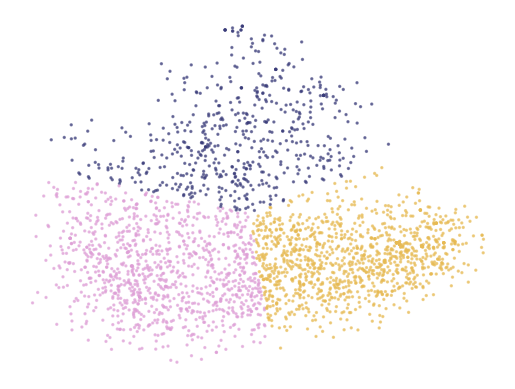

In [38]:
import matplotlib.pyplot as plt

# Plot outliers and non-outliers seperately
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_df.x, clusters_df.y, c=clusters_df.cluster.astype(int),
    alpha=0.6, s=2, cmap='tab20b'
)
plt.axis('off')
# plt.savefig("matplotlib.png", dpi=300)  # Uncomment to save the graph as a .png

# From Text Clustering to Topic Modeling

## **BERTopic: A Modular Topic Modeling Framework**

In [39]:
!pip install -q bertopic openai datasets datamapplot

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.1/49.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 13.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rapids-dask-dependency 25.6.0 requires dask==2025.5.0, but you have dask 2024.12.1 which is incompatible.
rapids-dask-dependency 25.6.0 requires distribut

In [41]:
# # Extract metadata and convert to standard list
abstracts = [t['abstract'] for t in titles_and_abstracts]
titles = [t['title'] for t in titles_and_abstracts]

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from umap import UMAP
from hdbscan import HDBSCAN
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired, MaximalMarginalRelevance, TextGeneration, OpenAI
from transformers import pipeline
from wordcloud import WordCloud
import openai
from copy import deepcopy
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from google.colab import userdata

def find_best_k(embeddings, k_min=2, k_max=15, random_state=42):
    """Return best k based on silhouette score"""
    best_score = -1
    best_k = k_min
    for k in range(k_min, k_max + 1):
        kmeans = KMeans(n_clusters=k, random_state=random_state).fit(embeddings)
        score = silhouette_score(embeddings, kmeans.labels_)
        if score > best_score:
            best_score = score
            best_k = k
    print(f"✅ Best k for KMeans: {best_k} with silhouette {best_score:.3f}")
    return best_k

# ==================== Helper Functions ====================
def topic_differences(model, original_topics, nr_topics=5):
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]
    return df

def create_wordcloud(model, topic, save_path=None):
    """Generate a wordcloud for a given topic if it exists."""
    topic_words = model.get_topic(topic)
    if not topic_words:  # Returns False if topic does not exist
        print(f"⚠️ Topic {topic} does not exist. Skipping wordcloud.")
        return

    plt.figure(figsize=(10,5))
    text = {word: value for word, value in topic_words}
    wc = WordCloud(background_color="white", max_words=1000, width=1600, height=800)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.close()


def save_document_visualization(model, documents, reduced_embeddings, save_path=None):
    fig = model.visualize_documents(
        documents,
        reduced_embeddings=reduced_embeddings,
        width=1200,
        hide_annotations=True
    )
    fig.update_layout(font=dict(size=16))
    if save_path:
        fig.write_html(save_path)
    plt.close()

def get_cluster_info(model, documents):
    """Return a dict with each cluster's top sentences and topic labels"""
    clusters = {}
    topics = model.get_document_info(documents)
    for topic_id in topics['Topic'].unique():
        if topic_id == -1:
            continue
        cluster_docs = topics[topics.Topic==topic_id]['Document'].tolist()
        label = model.get_topic(topic_id)
        clusters[topic_id] = {
            "top_sentences": cluster_docs[:5],  # top 5 representative sentences
            "topic_label": model.get_topic_info().loc[model.get_topic_info().Topic==topic_id, "Name"].values[0]
        }
    return clusters



# ==================== Config ====================
embedding_models = {
    "gte-small": "thenlper/gte-small",
    "multilingual-e5-large": "intfloat/multilingual-e5-large-instruct"
}

dim_reduction_models = {
    "umap": UMAP(n_components=5, min_dist=0.0, metric="cosine", random_state=42),
    "pca": PCA(n_components=5, random_state=42)
}

clustering_models = {
    "hdbscan": HDBSCAN(min_cluster_size=10, metric="euclidean", cluster_selection_method="eom"),
    "dbscan": DBSCAN(eps=0.01, min_samples=5, metric="euclidean"),
    "kmeans": KMeans(n_clusters=10, random_state=42)
}

results = {}

output_dir = "bertopic_outputs"
os.makedirs(output_dir, exist_ok=True)

# ==================== Main Loop ====================
for emb_name, emb_model_name in embedding_models.items():
    print(f"\n==== Embedding Model: {emb_name} ====")

    # Load embedding model
    embedding_model = SentenceTransformer(emb_model_name)
    embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

    for dim_name, dim_model in dim_reduction_models.items():
        reduced_embeddings = dim_model.fit_transform(embeddings)

        for clust_name, clust_model in clustering_models.items():

            # If KMeans, find optimal k
            if clust_name == "kmeans":
                best_k = find_best_k(reduced_embeddings, k_min=2, k_max=15)
                clust_model = KMeans(n_clusters=best_k, random_state=42)

            model_name = f"{emb_name}_{dim_name}_{clust_name}"
            print(f"\n--- {model_name} ---")

            # Create output folder
            model_dir = os.path.join(output_dir, model_name)
            os.makedirs(model_dir, exist_ok=True)

            # Build BERTopic model
            topic_model = BERTopic(
                embedding_model=embedding_model,
                umap_model=dim_model if dim_name=="umap" else None,
                hdbscan_model=clust_model if clust_name=="hdbscan" else None,
                verbose=False
            )

            # Fit model
            topics, probs = topic_model.fit_transform(abstracts, embeddings)

            # Get topic info
            info = topic_model.get_topic_info()

            # Exclude outlier topic (-1)
            num_clusters = len(info[info.Topic != -1])
            print(f"✅ Number of clusters (excluding outliers): {num_clusters}")

            # Save original topic representations
            original_topics = deepcopy(topic_model.topic_representations_)

            # ===== Update representations =====
            topic_model.update_topics(abstracts, representation_model=KeyBERTInspired())
            topic_model.update_topics(abstracts, representation_model=MaximalMarginalRelevance(diversity=0.5))
            generator = pipeline("text2text-generation", model="google/flan-t5-small")
            topic_model.update_topics(abstracts, representation_model=TextGeneration(generator, prompt="Topic: [KEYWORDS]\nDocs: [DOCUMENTS]"))
            client = openai.OpenAI(api_key=userdata.get("openaikey"))
            topic_model.update_topics(abstracts, representation_model=OpenAI(client, model="gpt-3.5-turbo", chat=True, prompt="topic: <label>"))

            # ===== Save visualizations =====
            save_document_visualization(topic_model, abstracts, reduced_embeddings, save_path=os.path.join(model_dir, "document_vis.html"))

            # Wordclouds for first 5 topics
            for topic_id in range(5):
                create_wordcloud(topic_model, topic_id, save_path=os.path.join(model_dir, f"wordcloud_topic{topic_id}.png"))

            # ===== Cluster info and topic labels =====
            clusters_info = get_cluster_info(topic_model, abstracts)
            # Save cluster info as JSON
            # import json
            # with open(os.path.join(model_dir, "clusters_info.json"), "w", encoding="utf-8") as f:
            #     json.dump(clusters_info, f, indent=2, ensure_ascii=False)

            # Print top topic labels
            for cid, cinfo in clusters_info.items():
                print(f"Cluster {cid}: Label = {cinfo['topic_label']}")
                for sent in cinfo['top_sentences']:
                    print(f"  - {sent}")

            # Path to save the cluster info
            txt_file_path = os.path.join(model_dir, "clusters_info.txt")

            with open(txt_file_path, "w", encoding="utf-8") as f:
                for cid, cinfo in clusters_info.items():
                    f.write(f"Cluster {cid}: Label = {cinfo['topic_label']}\n")
                    for sent in cinfo['top_sentences']:
                        f.write(f"  - {sent}\n")
                    f.write("\n")  # Add a newline between clusters

            print(f"✅ Cluster info saved to {txt_file_path}")


            results[model_name] = topic_model



==== Embedding Model: gte-small ====


Batches:   0%|          | 0/87 [00:00<?, ?it/s]


--- gte-small_umap_hdbscan ---
✅ Number of clusters (excluding outliers): 48


Device set to use cuda:0
Token indices sequence length is longer than the specified maximum sequence length for this model (2393 > 512). Running this sequence through the model will result in indexing errors
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [22]:
from bertopic import BERTopic

# Train our model with our previously defined models
topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2025-08-21 13:21:35,891 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-08-21 13:21:52,583 - BERTopic - Dimensionality - Completed ✓
2025-08-21 13:21:52,585 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-08-21 13:21:52,745 - BERTopic - Cluster - Completed ✓
2025-08-21 13:21:52,753 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-08-21 13:21:53,060 - BERTopic - Representation - Completed ✓


Now, let's start exploring the topics that we got by running the code above.

In [23]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,925,-1_to_the_and_it,"[to, the, and, it, of, for, that, is, 4o, in]",[please keep 45 its just really saddening how...
1,0,271,0_gpt5_gpt_the_to,"[gpt5, gpt, the, to, is, and, it, thinking, we...",[there is huge difference between quality of g...
2,1,161,1_context_window_32k_128k,"[context, window, 32k, 128k, for, plus, tokens...",[there should be some context window upgrade f...
3,2,141,2_chatgpt_it_and_the,"[chatgpt, it, and, the, to, chat, my, me, in, ...",[ive been using chatgpt for over 3 years now a...
4,3,101,3_models_legacy_the_users,"[models, legacy, the, users, model, to, you, b...",[since you already have them available for pro...
5,4,92,4_spaghetti_ding_word_smith,"[spaghetti, ding, word, smith, eating, very, b...",[yes it sees everything and i mean everything ...
6,5,91,5_safety_the_for_censorship,"[safety, the, for, censorship, that, you, and,...",[can you do something about the filter surely ...
7,6,88,6_back_bring_4o_please,"[back, bring, 4o, please, friend, we, plz, quo...","[please bring 4o back, please bring 4o back, b..."
8,7,75,7_plus_limits_limit_unlimited,"[plus, limits, limit, unlimited, the, to, user...",[was a plus subscriber for 12 months unsubscri...
9,8,75,8_voice_standard_mode_advanced,"[voice, standard, mode, advanced, cove, the, a...",[i appreciate the innovation truly but the dec...


Hundreds of topics were generated using the default model! To get the top 10 keywords per topic as well as their c-TF-IDF weights, we can use the `get_topic()` function:

In [24]:
topic_model.get_topic(11)

[('ai', np.float64(0.028120414327109884)),
 ('you', np.float64(0.022267976264256587)),
 ('to', np.float64(0.01869315587356905)),
 ('people', np.float64(0.01805984054476576)),
 ('of', np.float64(0.01746816001633518)),
 ('are', np.float64(0.01741853056371825)),
 ('and', np.float64(0.017319329947253423)),
 ('that', np.float64(0.01720126184005829)),
 ('human', np.float64(0.0163825121082906)),
 ('in', np.float64(0.016173255915555514))]

We can use the `find_topics()` function to search for specific topics based on a search term. Let’s search for a topic about topic modeling:

In [1]:
topic_model.find_topics("gpt 4o")

NameError: name 'topic_model' is not defined

It returns that topic 22 has a relatively high similarity (0.95) with our search term. If we then inspect the topic, we can see that it is indeed a topic about topic modeling:

In [26]:
topic_model.get_topic(24)

[('ama', np.float64(0.14296114324905398)),
 ('answer', np.float64(0.0585896470900107)),
 ('really', np.float64(0.04855869066680482)),
 ('respond', np.float64(0.0456953566982702)),
 ('they', np.float64(0.04130791388348487)),
 ('other', np.float64(0.04122882050369527)),
 ('only', np.float64(0.03945307100459033)),
 ('lmao', np.float64(0.037113836874661625)),
 ('did', np.float64(0.03603870760540386)),
 ('answered', np.float64(0.033585431004039434))]

That seems like a topic that is, in part, characterized by the classic LDA technique. Let's see if the BERTopic paper was also assigned to topic 22:

In [27]:
# topic_model.topics_[titles.index('BERTopic: Neural topic modeling with a class-based TF-IDF procedure')]

In [28]:
# topic_model.topics_[titles.index('Attention Is All You Need')]

It is! We expected it might be because there are non-LDA specific words in the topic describtion such as "clustering" and "topic".

### **Visualizations**

**Visualize Documents**

In [29]:
# Visualize topics and documents
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

# Update fonts of legend for easier visualization
fig.update_layout(font=dict(size=16))

In [30]:
# Visualize barchart with ranked keywords
topic_model.visualize_barchart()

# Visualize relationships between topics
topic_model.visualize_heatmap(n_clusters=30)

# Visualize the potential hierarchical structure of topics
topic_model.visualize_hierarchy()

## **Representation Models**

In [ ]:
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

# Create your representation model
representation_model = KeyBERTInspired()

# Use the representation model in BERTopic on top of the default pipeline
topic_model = BERTopic(representation_model=representation_model)

# Save original representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between two models """
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df

import pandas as pd
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

from bertopic.representation import MaximalMarginalRelevance

# Update our topic representations to MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(abstracts, representation_model=representation_model)


# Show topic differences
topic_differences(topic_model, original_topics)

from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""

# Update our topic representations using Flan-T5
generator = pipeline('text2text-generation', model='google/flan-t5-small')
representation_model = TextGeneration(
    generator, prompt=prompt, doc_length=50, tokenizer="whitespace"
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)


import openai
from bertopic.representation import OpenAI
from google.colab import userdata


prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short topic label in the following format:
topic: <short topic label>
"""

# Update our topic representations using GPT-3.5
client = openai.OpenAI(api_key=userdata.get('openaikey'))
representation_model = OpenAI(
    client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

topic_model.update_topics(abstracts, top_n_words=500)

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(model, topic):
    plt.figure(figsize=(10,5))
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000, width=1600, height=800)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud
create_wordcloud(topic_model, topic=17)

# 1) Get the DataFrame of topics
import pandas as pd

info: pd.DataFrame = topic_model.get_topic_info()
# info has columns: ["Topic", "Count", "Name"], and row 0 is the outlier topic -1

# 2) Filter out the “-1” outlier (if you like) and display
filtered = info[info.Topic != -1]

# 3) Print Topic ID → Label
for _, row in filtered.iterrows():
    print(f"Topic-{int(row.Topic)}: {row.Name}")


In these examples that follow, we will update our topic representations **after** having trained our model. This allows for quick iteration. If, however, you want to use a representation model at the start of training, you will need to run it as follows:

```python
from bertopic.representation import KeyBERTInspired
from bertopic import BERTopic

# Create your representation model
representation_model = KeyBERTInspired()

# Use the representation model in BERTopic on top of the default pipeline
topic_model = BERTopic(representation_model=representation_model)
```

To use the representation models, we are first going to duplicate our topic model such that easily show the differences between a model with and without representation model.

In [31]:
# Save original representations
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [32]:
def topic_differences(model, original_topics, nr_topics=5):
    """Show the differences in topic representations between two models """
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):

        # Extract top 5 words per topic per model
        og_words = " | ".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = " | ".join(list(zip(*model.get_topic(topic)))[0][:5])
        df.loc[len(df)] = [topic, og_words, new_words]

    return df

### KeyBERTInspired

In [33]:
import pandas as pd
from bertopic.representation import KeyBERTInspired

# Update our topic representations using KeyBERTInspired
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,gpt5 | gpt | the | to | is,gpt5 | gpt | gpt4 | gpt4o | 4o
1,1,context | window | 32k | 128k | for,context | chatgpt | window | plus | chat
2,2,chatgpt | it | and | the | to,chatgpt | chatgpt4o | chat | gpt | gpt5
3,3,models | legacy | the | users | model,models | legacy | model | users | preferences
4,4,spaghetti | ding | word | smith | eating,will | see | live | wow | look




```
# This is formatted as code
```

### Maximal Marginal Relevance

In [34]:
from bertopic.representation import MaximalMarginalRelevance

# Update our topic representations to MaximalMarginalRelevance
representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(abstracts, representation_model=representation_model)


# Show topic differences
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,gpt5 | gpt | the | to | is,gpt5 | to | thinking | we | 4o
1,1,context | window | 32k | 128k | for,context | 128k | plus | tokens | is
2,2,chatgpt | it | and | the | to,chatgpt | to | chat | me | in
3,3,models | legacy | the | users | model,models | legacy | users | back | plus
4,4,spaghetti | ding | word | smith | eating,spaghetti | ding | smith | blueberry | bar


## Text Generation



### Flan-T5

In [35]:
from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""

# Update our topic representations using Flan-T5
generator = pipeline('text2text-generation', model='google/flan-t5-small')
representation_model = TextGeneration(
    generator, prompt=prompt, doc_length=50, tokenizer="whitespace"
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
100%|██████████| 45/45 [00:37<00:00,  1.20it/s]


,Topic,Original,Updated
0,0,gpt5 | gpt | the | to | is,Science/Tech | | | |
1,1,context | window | 32k | 128k | for,Science/Tech | | | |
2,2,chatgpt | it | and | the | to,chatgpt | | | |
3,3,models | legacy | the | users | model,- please bring back legacy models for plus use...
4,4,spaghetti | ding | word | smith | eating,"spaghetti, ding | | | |"


### OpenAI

In [36]:
import openai
from bertopic.representation import OpenAI
from google.colab import userdata


prompt = """
I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: [KEYWORDS]

Based on the information above, extract a short topic label in the following format:
topic: <short topic label>
"""

# Update our topic representations using GPT-3.5
client = openai.OpenAI(api_key=userdata.get('openaikey'))
representation_model = OpenAI(
    client, model="gpt-3.5-turbo", exponential_backoff=True, chat=True, prompt=prompt
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# Show topic differences
topic_differences(topic_model, original_topics)

100%|██████████| 45/45 [00:37<00:00,  1.19it/s]


,Topic,Original,Updated
0,0,gpt5 | gpt | the | to | is,Comparison of GPT5 and GPT4o Models and Feedba...
1,1,context | window | 32k | 128k | for,Context Window Upgrade for Plus and Pro Users
2,2,chatgpt | it | and | the | to,Issues with ChatGPT 5 and Desire for Earlier M...
3,3,models | legacy | the | users | model,Legacy Models Accessibility for Plus Users
4,4,spaghetti | ding | word | smith | eating,Tech innovations and infrastructure optimizati...



## **BONUS**: Word Cloud

Make sure to pip install `wordcloud` first in order to follow this bonus:


First, we need to make sure that each topic is described by a bit more words than just 10 as that would make for a much more interesting wordcloud.

In [37]:
topic_model.update_topics(abstracts, top_n_words=500)

2025-08-21 13:24:18,621 - BERTopic - WARNING: Note that extracting more than 100 words from a sparse can slow down computation quite a bit.


Then, we can run the following code to generate the wordcloud for our topic modeling topic:

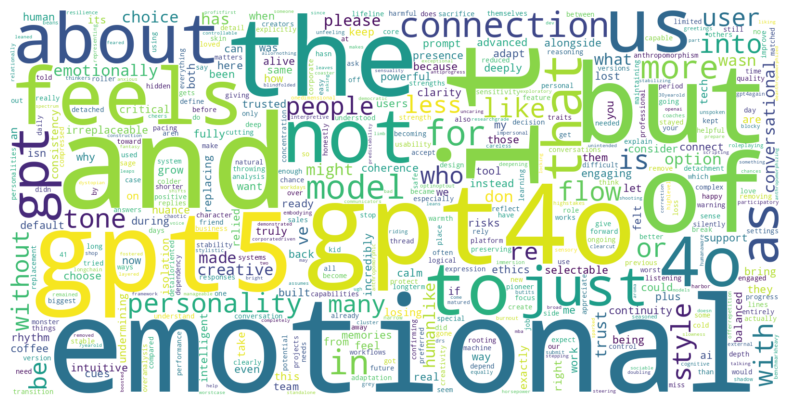

In [38]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

def create_wordcloud(model, topic):
    plt.figure(figsize=(10,5))
    text = {word: value for word, value in model.get_topic(topic)}
    wc = WordCloud(background_color="white", max_words=1000, width=1600, height=800)
    wc.generate_from_frequencies(text)
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Show wordcloud
create_wordcloud(topic_model, topic=17)

In [39]:
# 1) Get the DataFrame of topics
import pandas as pd

info: pd.DataFrame = topic_model.get_topic_info()
# info has columns: ["Topic", "Count", "Name"], and row 0 is the outlier topic -1

# 2) Filter out the “-1” outlier (if you like) and display
filtered = info[info.Topic != -1]

# 3) Print Topic ID → Label
for _, row in filtered.iterrows():
    print(f"Topic-{int(row.Topic)}: {row.Name}")


Topic-0: 0_gpt5_gpt_the_to
Topic-1: 1_context_window_32k_128k
Topic-2: 2_chatgpt_it_and_the
Topic-3: 3_models_legacy_the_users
Topic-4: 4_spaghetti_ding_word_smith
Topic-5: 5_safety_the_for_censorship
Topic-6: 6_back_bring_4o_please
Topic-7: 7_plus_limits_limit_unlimited
Topic-8: 8_voice_standard_mode_advanced
Topic-9: 9_thank_you_much_thanks
Topic-10: 10_4o_it_to_personality
Topic-11: 11_ai_you_to_people
Topic-12: 12_gpt4o_emotional_and_of
Topic-13: 13_41_4o_both_please
Topic-14: 14_they_company_product_their
Topic-15: 15_45_50_40_was
Topic-16: 16_openai_will_this_the
Topic-17: 17_it_emotional_and_gpt4o
Topic-18: 18_4o_enough_suffice_fix
Topic-19: 19_yes_undone_woah_expanding
Topic-20: 20_41_please_back_too
Topic-21: 21_plus_users_4o_back
Topic-22: 22_em_dashes_dash_emdashes
Topic-23: 23_yes_please_quick_god
Topic-24: 24_ama_answer_really_respond
Topic-25: 25_deleted_removed_voracious_redact
Topic-26: 26_worse_bad_it_much
Topic-27: 27_writing_character_it_to
Topic-28: 28_agreed_agreei